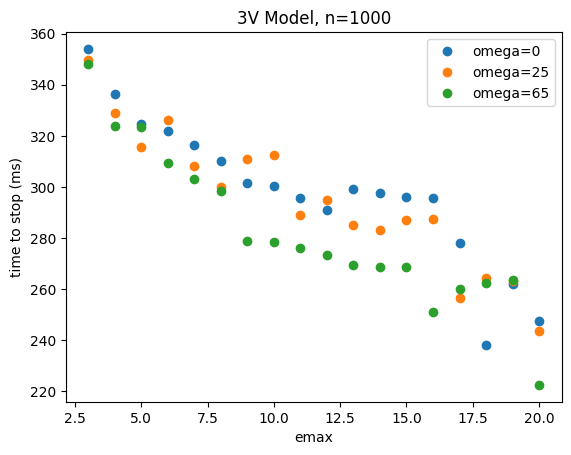

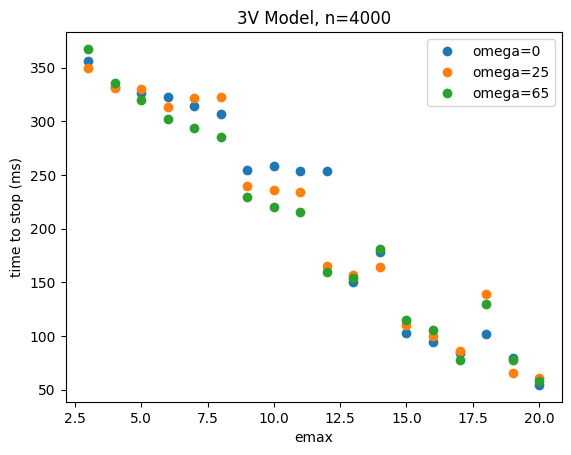

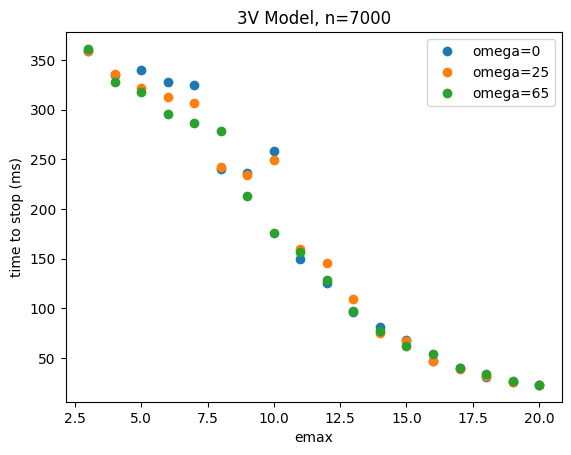

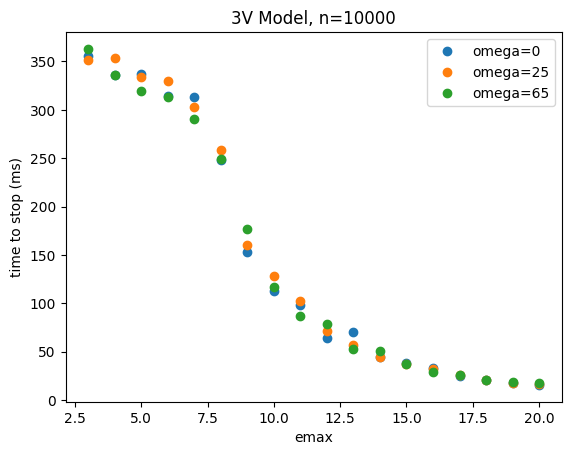

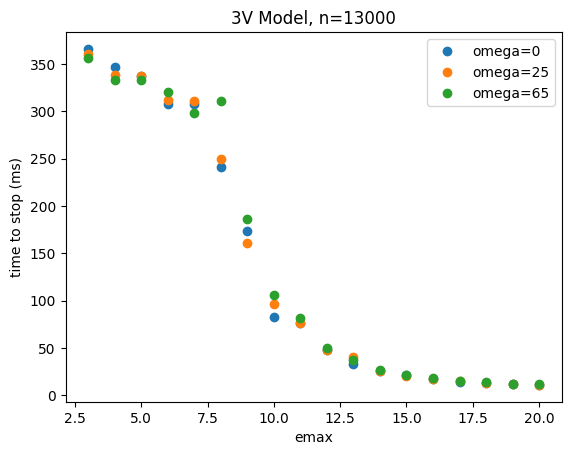

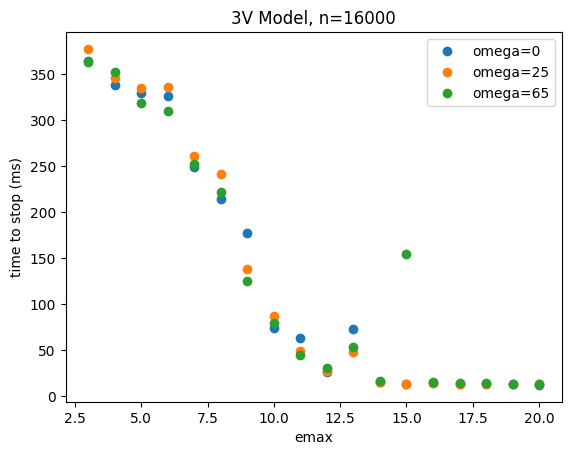

In [6]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

time_to_stop = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
colors = ['#2b4fa2','#ed1c24','#007c40','#000001','#00babb','#a33694','#bcbe32']
data2 = {}
dt = 0.5

with open('FTE_results_omega0_diff_mask_taupw and tausi and ulower range modified.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)_n(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            omega_idx = int(match.group(3))
            n_idx = int(match.group(4))
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if omega_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][omega_idx] = {}
            if n_idx not in data2[i_idx][j_idx][omega_idx]:
                data2[i_idx][j_idx][omega_idx][n_idx] = []
            
            data2[i_idx][j_idx][omega_idx][n_idx] = values
for E_max in sorted(data2[0].keys()):
    for IC_idx in data2.keys():
        for omega_idx in data2[IC_idx][E_max].keys():
            for n_idx in data2[IC_idx][E_max][omega_idx].keys():
                threshold = max(data2[IC_idx][E_max][omega_idx][n_idx]) 
                for t_idx, val in enumerate(data2[IC_idx][E_max][omega_idx][n_idx]):
                    if val and val >= threshold:
                        time_to_stop[E_max][omega_idx][n_idx] = dt * t_idx
                        break


for n_idx in sorted(data2[0][E_max][0].keys()):
    plt.figure()
    for omega in sorted(data2[0][E_max].keys()):
        temp = []
        emax = []
        for E_max in sorted(data2[0].keys()):
            emax.append(E_max)
            temp.append(time_to_stop[E_max][omega][n_idx])
        plt.plot(emax,temp,'o',label=f'omega={omega}')
        plt.legend()
        plt.xlabel('emax')
        plt.legend()
        plt.ylabel('time to stop (ms)')
        #plt.savefig('time_to_stop_vs_emax_etimeact.png')
        plt.title(f'3V Model, n={n_idx}')
    plt.savefig(f'time_to_stop_vs_emax_omega_diff_n{n_idx}.png')
